In [1]:
import seaborn as sns
import os
from scipy.stats import kurtosis, skew
import pickle

from rcv_distribution import *
from MDS_analysis import *
from voting_rules import *
import random
from itertools import permutations
from collections import defaultdict
from collections import Counter

c:\Users\mahsh\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mahsh\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
c:\Users\mahsh\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
directory = "dataverse_files"
table = pd.read_csv("diff.csv")
for filename in os.listdir(directory):
    try:
        csv = os.path.join(directory, filename)
        ballots, candidates = parse_election_data(csv)

        # Perform the RCV analysis
        test = perform_rcv_analysis(ballots, candidates, n_init = 100, max_itr = 1000, n_runs=1000, metric=False)
        mds_1d_coordinates, mds_2d_coordinates, most_common_order, order_frequencies, candidate_names = test

        # Print the normalized distances between candidates and plot the MDS analysis
        normalized_distances_original = get_distances_normalized(most_common_order, mds_1d_coordinates, candidate_names)

        consistent_ballots, gamma = get_permissive_gamma(ballots, normalized_distances_original)
        table.loc[table["filename"]==filename, "gamma_n_init"] = gamma

        plot_KDE(ballots, normalized_distances_original, filename, ignore=False, save=True)

        freqs = get_frequency(ballots, candidates)
        ignore = [] 
        for c in freqs:
            if freqs[c] < 0.02:
                ignore.append(c)
        if len(ignore) > 0:
            ballots, candidates = parse_election_data(os.path.join("dataverse_files", filename), ignore_values=ignore)
            # Perform the RCV analysis
            test = perform_rcv_analysis(ballots, candidates, n_init = 100, max_itr = 1000, n_runs=1000, metric=False)
            mds_1d_coordinates, mds_2d_coordinates, most_common_order, order_frequencies, candidate_names = test

            # Get the normalized distances between candidates and plot the MDS analysis
            normalized_distances_ignored = get_distances_normalized(most_common_order, mds_1d_coordinates, candidate_names)

            consistent_ballots, gamma = get_permissive_gamma(ballots, normalized_distances_ignored)

            table.loc[table["filename"]==filename, "gamma_ignored"] = gamma

            plot_KDE(ballots, normalized_distances_original, filename, ignore=True, save=True)
    
    except Exception as e:
        # Print the summary of the error
        print(f"An error occurred: {e}")

table.to_csv("diff2.csv")


In [2]:
def save_data(filename, data_dict, data_list, save_folder):
    # Extract the base filename without extension
    base_filename = os.path.splitext(os.path.basename(filename))[0]

    # Create the save paths for dictionary and list
    dict_save_path = os.path.join(save_folder, f"{base_filename}_ballots.pkl")
    list_save_path = os.path.join(save_folder, f"{base_filename}_candidates.pkl")

    # Save the dictionary
    with open(dict_save_path, 'wb') as dict_file:
        pickle.dump(data_dict, dict_file)

    # Save the list
    with open(list_save_path, 'wb') as list_file:
        pickle.dump(data_list, list_file)

In [4]:
def load_data(filename, save_folder):
    # Extract the base filename without extension
    base_filename = os.path.splitext(os.path.basename(filename))[0]

    # Create the save paths for dictionary and list
    dict_load_path = os.path.join(save_folder, f"{base_filename}_dict.pkl")
    list_load_path = os.path.join(save_folder, f"{base_filename}_list.pkl")

    # Load the dictionary
    with open(dict_load_path, 'rb') as dict_file:
        data_dict = pickle.load(dict_file)

    # Load the list
    with open(list_load_path, 'rb') as list_file:
        data_list = pickle.load(list_file)

    return data_dict, data_list



In [ ]:
directory = "dataverse_files_2025"
election_table = pd.read_csv("election_table.csv")

for filename in os.listdir(directory):
    
    try:
        with open("saved_ballots_and_candidates/" + filename[0: -4]+"_ballots.pkl", "rb") as f:   # always open in *rb*
            ballots = pickle.load(f)
        with open("saved_ballots_and_candidates/" + filename[0: -4]+"_candidates.pkl", "rb") as f:   # always open in *rb*
            candidates = pickle.load(f)

        for b in list(ballots):
            if len(b) <= 2:
                del ballots[b]

        test = perform_rcv_analysis(ballots, candidates, n_init = 100, max_itr = 1000, n_runs=1000, metric=False)
        mds_1d_coordinates, mds_2d_coordinates, most_common_order, order_frequencies, candidate_names = test

        # Print the normalized distances between candidates and plot the MDS analysis
        normalized_distances_original = get_distances_normalized(most_common_order, mds_1d_coordinates, candidate_names)
        
        complete_gamma = get_permissive_gamma(ballots, normalized_distances_original)[1]

        election_table.loc[election_table['filename']==filename, 'complete_gamma'] = complete_gamma
    
    except Exception as e:
        print(filename, " ", e)
election_table.to_csv("election_table(2).csv")

In [4]:
csv = "NewYorkCity_20250624_DEMMayorCitywide.csv"
ballots, candidates = parse_election_data(csv)
filename = csv[0:-4]
save_data(filename, ballots, candidates, "saved_ballots_and_candidates")
test = perform_rcv_analysis(ballots, candidates, n_init = 100, max_itr=100, n_runs=1000, metric=False)
mds_1d_coordinates, mds_2d_coordinates, most_common_order, order_frequencies, candidate_names = test

# Print the normalized distances between candidates and plot the MDS analysis
normalized_distances = get_distances_normalized(most_common_order, mds_1d_coordinates, candidate_names)
print("Normalized distances:", normalized_distances)

plot_KDE(ballots, normalized_distances, csv, ignore=False, save=True, directory="KDE_new")

c:\Users\mahsh\Documents\GitHub\bugs-in-democracy\cleaned files\MDS_analysis.py:162: RuntimeWarning: divide by zero encountered in divide
  distance = 1 / np.sqrt(freq_upper_triangle)


Normalized distances: {'Paperboy Love Prince': 0.0, 'Zohran Kwame Mamdani': 4.527283578103614, 'Brad Lander': 5.0113473596133415, 'Michael Blake': 5.506079333969995, 'Zellnor Myrie': 6.209876807658178, 'Adrienne E. Adams': 6.429977215260275, 'Jessica Ramos': 7.064648748307471, 'Scott M. Stringer': 7.269008656967356, 'Andrew M. Cuomo': 8.05159339607918, 'Whitney R. Tilson': 8.756570338572418, 'Selma K. Bartholomew': 10.0}


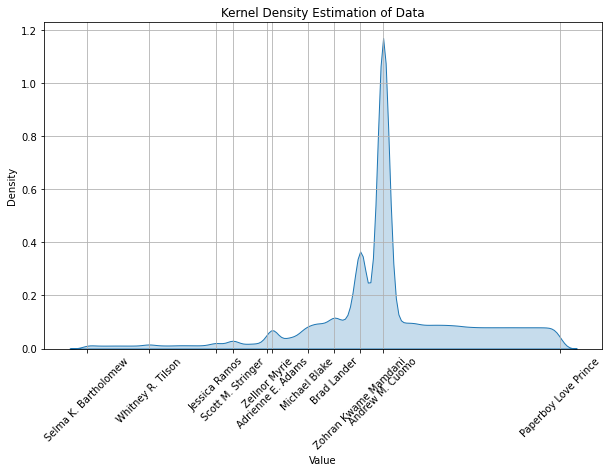

In [11]:

plot_KDE(ballots, normalized_distances, csv, ignore=False, save=False, directory="KDE_new")

In [17]:
print("Permissive Gamma coefficiet:", get_permissive_gamma(ballots, normalized_distances)[1])

Permissive Gamma coefficiet: 0.7041749056894835


In [13]:
freq = get_frequency(ballots, candidates)
ignore = []
for c in candidates:
    if freq[c] < 0.01:
        ignore.append(c)

print(ignore)

['Selma K. Bartholomew', 'Jessica Ramos', 'Whitney R. Tilson', 'Michael Blake', 'Paperboy Love Prince']


In [ ]:
plot_KDE(ballots, normalized_distances, csv, ignore=False, save=False, directory="KDE_new")

In [14]:
csv = "NewYorkCity_20250624_DEMMayorCitywide.csv"

ballots, candidates = parse_election_data(csv, ignore_values=ignore)
print(candidates)

['Andrew M. Cuomo', 'Brad Lander', 'Zohran Kwame Mamdani', 'Adrienne E. Adams', 'Scott M. Stringer', 'Zellnor Myrie']


In [15]:
test = perform_rcv_analysis(ballots, candidates, n_init = 100, max_itr=100, n_runs=1000, metric=False)
mds_1d_coordinates, mds_2d_coordinates, most_common_order, order_frequencies, candidate_names = test

# Print the normalized distances between candidates and plot the MDS analysis
normalized_distances_original = get_distances_normalized(most_common_order, mds_1d_coordinates, candidate_names)
print("Normalized distances:", normalized_distances_original)

c:\Users\mahsh\Documents\GitHub\bugs-in-democracy\cleaned files\MDS_analysis.py:162: RuntimeWarning: divide by zero encountered in divide
  distance = 1 / np.sqrt(freq_upper_triangle)


Normalized distances: {'Zohran Kwame Mamdani': 0.0, 'Brad Lander': 1.291934299461529, 'Adrienne E. Adams': 1.9548422497902664, 'Zellnor Myrie': 2.355233224408702, 'Scott M. Stringer': 3.2823107411231156, 'Andrew M. Cuomo': 5.0}


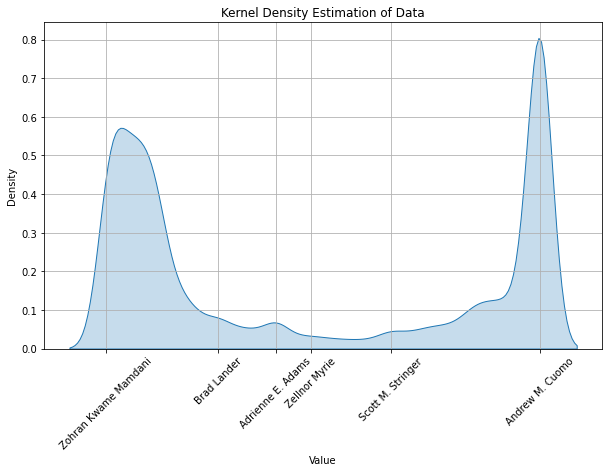

In [16]:
plot_KDE(ballots, normalized_distances_original, csv, ignore=False, save=False)

In [6]:
directory = "dataverse_files_only_after_2023"

for file in os.listdir(directory):
    try:
        csv = os.path.join(directory, file)
        ballots, candidates = parse_election_data(csv)
        filename = file[0:-4]
        save_data(filename, ballots, candidates, "saved_ballots_and_candidates")

        candidate_positions_file = pd.read_csv("null_elections/" + filename + ".csv")
        normalized_positions = pd.Series(candidate_positions_file['position'].values, index=candidate_positions_file['candidate']).to_dict()

        plot_KDE(ballots, normalized_positions, file, ignore=False, save=True, directory="KDE_new")

    except Exception as e:
        # Print the summary of the error
        print(file, " ", e)




Alaska_11052024_StateHouseD17.csv   [Errno 2] No such file or directory: 'null_elections/Alaska_11052024_StateHouseD17.csv'
Alaska_11052024_StateHouseD2.csv   [Errno 2] No such file or directory: 'null_elections/Alaska_11052024_StateHouseD2.csv'
Alaska_11052024_StateHouseD24.csv   [Errno 2] No such file or directory: 'null_elections/Alaska_11052024_StateHouseD24.csv'
Alaska_11052024_StateHouseD25.csv   [Errno 2] No such file or directory: 'null_elections/Alaska_11052024_StateHouseD25.csv'
Alaska_11052024_StateHouseD26.csv   [Errno 2] No such file or directory: 'null_elections/Alaska_11052024_StateHouseD26.csv'
Alaska_11052024_StateHouseD29.csv   [Errno 2] No such file or directory: 'null_elections/Alaska_11052024_StateHouseD29.csv'
Alaska_11052024_StateHouseD3.csv   [Errno 2] No such file or directory: 'null_elections/Alaska_11052024_StateHouseD3.csv'
Alaska_11052024_StateHouseD33.csv   [Errno 2] No such file or directory: 'null_elections/Alaska_11052024_StateHouseD33.csv'
Alaska_11052

In [7]:
import os
import numpy as np
import pandas as pd

# Define the paths
npy_folder = 'np_data_new'
csv_folder = 'csv_data'


# Iterate through each .npy file in np_data_new
for npy_file in os.listdir(npy_folder):
    if npy_file.endswith('.npy'):
        # Load the .npy file
        npy_path = os.path.join(npy_folder, npy_file)
        data = np.load(npy_path)

        # Convert to a DataFrame
        df = pd.DataFrame(data)

        # Define the new file path in csv_data with the same name but .csv extension
        csv_file = os.path.join(csv_folder, npy_file.replace('.npy', '.csv'))
        
        # Save the DataFrame as a CSV
        df.to_csv(csv_file, index=False)

print("Conversion complete.")


Conversion complete.
